In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline

In [3]:
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species_name'] = df['species'].map(species_map)

print("="*60)
print("FIRST 10 ROWS")
print("="*60)
print(df.head(10))

FIRST 10 ROWS
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0  

In [4]:
print("\n" + "="*60)
print("DATASET SHAPE & INFO")
print("="*60)
print(f"Shape: {df.shape}")
print(df.info())

print("\n" + "="*60)
print("STATISTICAL SUMMARY (overall)")
print("="*60)
print(df.describe())

print("\n" + "="*60)
print("STATISTICAL SUMMARY (per species)")
print("="*60)
print(df.groupby('species_name')[iris.feature_names].describe().T)


DATASET SHAPE & INFO
Shape: (150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

STATISTICAL SUMMARY (overall)
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000         

In [5]:
print("\n" + "="*60)
print("DUPLICATE ROWS")
print("="*60)
print(f"Number of duplicates: {df.duplicated().sum()}")

print("\n" + "="*60)
print("CLASS BALANCE")
print("="*60)
print(df['species_name'].value_counts())
print("-> Perfectly balanced: 50 samples per class, no class-imbalance issues.")



DUPLICATE ROWS
Number of duplicates: 1

CLASS BALANCE
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
-> Perfectly balanced: 50 samples per class, no class-imbalance issues.


In [6]:
print("\n" + "="*60)
print("SKEWNESS OF EACH FEATURE")
print("="*60)
print(df[iris.feature_names].skew())

print("\n" + "="*60)
print("CORRELATION MATRIX")
print("="*60)
print(df[iris.feature_names].corr())



SKEWNESS OF EACH FEATURE
sepal length (cm)    0.314911
sepal width (cm)     0.318966
petal length (cm)   -0.274884
petal width (cm)    -0.102967
dtype: float64

CORRELATION MATRIX
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


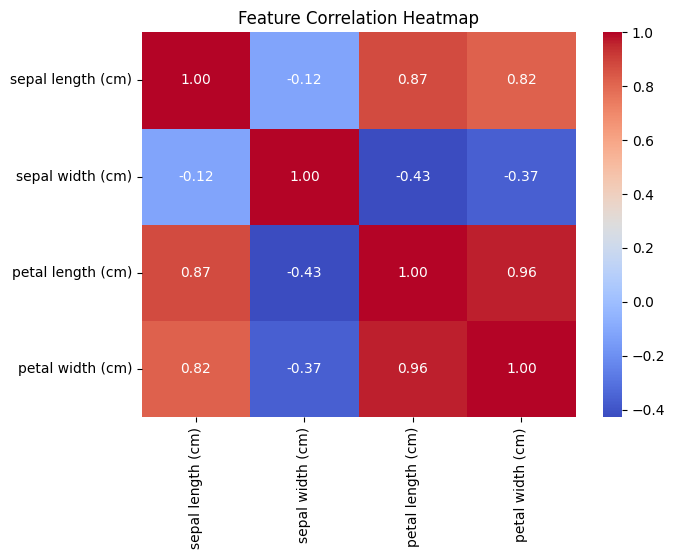

In [7]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[iris.feature_names].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()


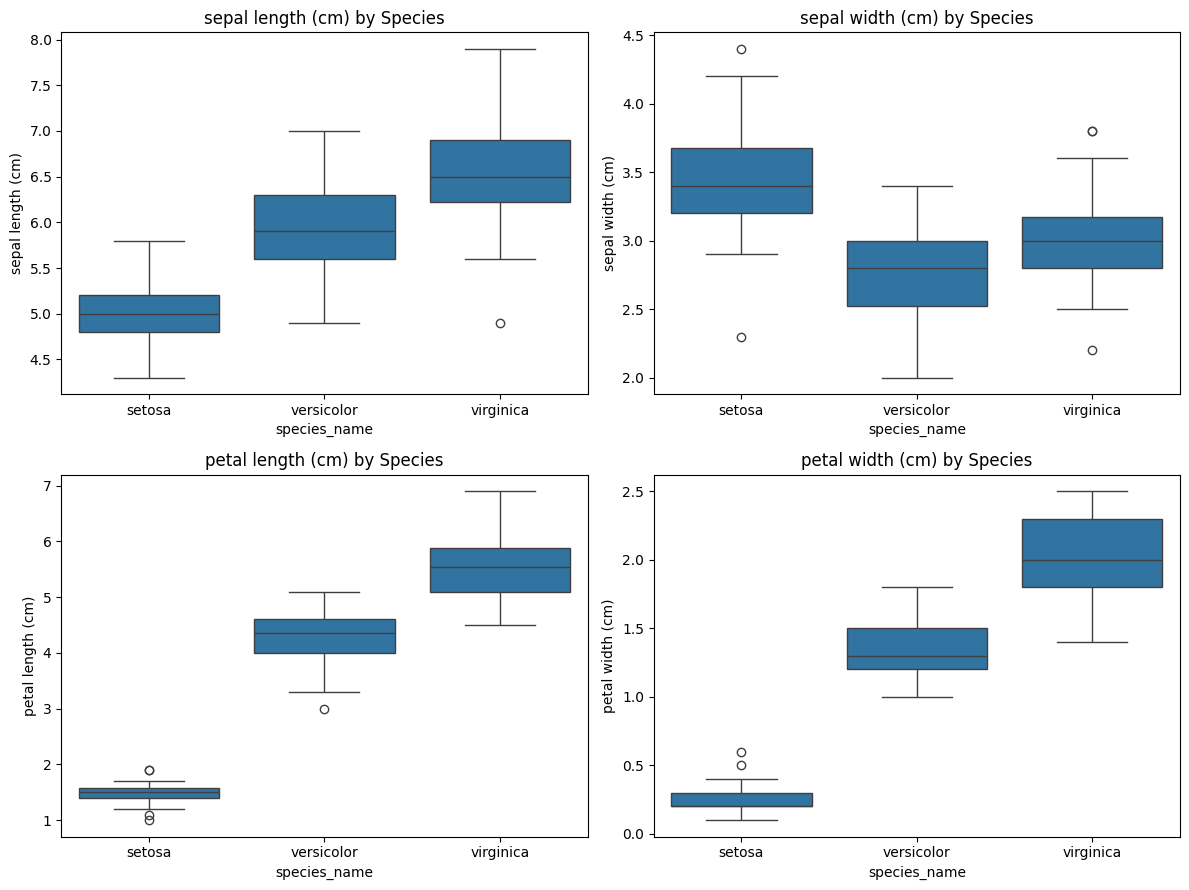

In [8]:
ig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feature in zip(axes.flatten(), iris.feature_names):
    sns.boxplot(x='species_name', y=feature, data=df, ax=ax)
    ax.set_title(f"{feature} by Species")
plt.tight_layout()
plt.show()

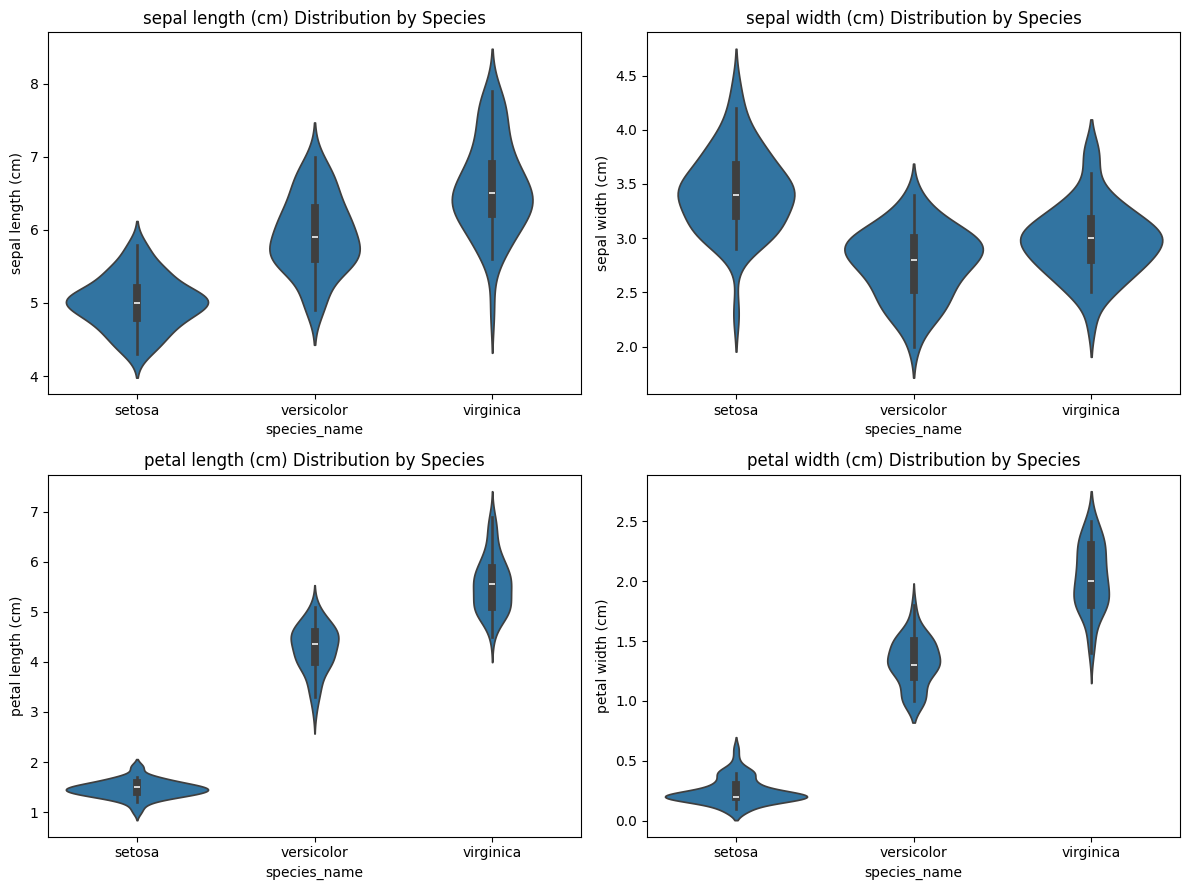

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feature in zip(axes.flatten(), iris.feature_names):
    sns.violinplot(x='species_name', y=feature, data=df, ax=ax)
    ax.set_title(f"{feature} Distribution by Species")
plt.tight_layout()
plt.show()

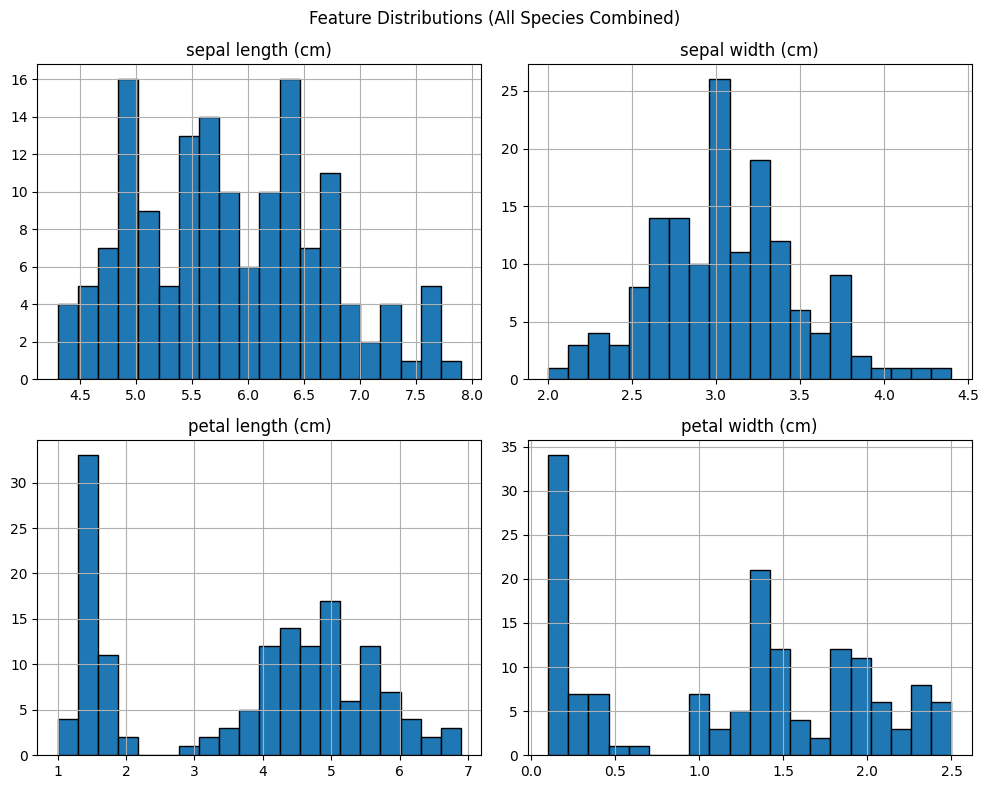

In [10]:
df[iris.feature_names].hist(figsize=(10, 8), bins=20, edgecolor='black')
plt.suptitle("Feature Distributions (All Species Combined)")
plt.tight_layout()
plt.show()

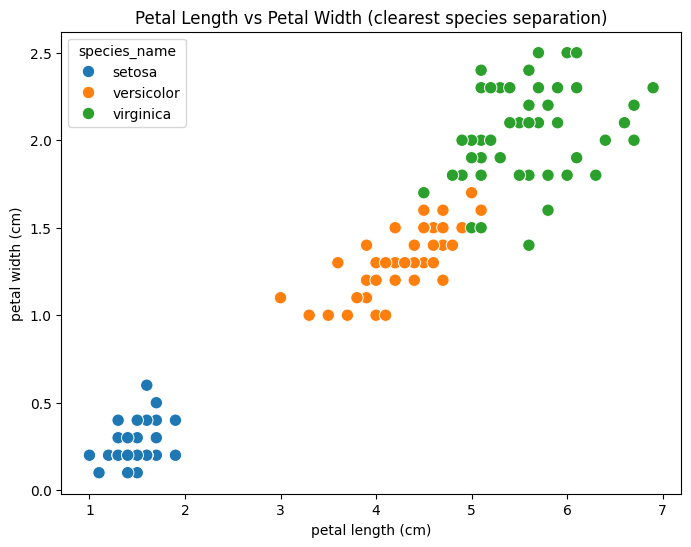


EDA INSIGHT: Petal length and petal width separate the species almost
perfectly, while sepal length/width overlap more between versicolor
and virginica. Setosa is linearly separable from the other two species
on every feature.


In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='species_name', data=df, s=80)
plt.title("Petal Length vs Petal Width (clearest species separation)")
plt.show()
print("\nEDA INSIGHT: Petal length and petal width separate the species almost")
print("perfectly, while sepal length/width overlap more between versicolor")
print("and virginica. Setosa is linearly separable from the other two species")
print("on every feature.")


In [12]:
X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Support Vector Machine": SVC(kernel='linear'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB()
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("\n" + "="*60)
print("10-FOLD CROSS-VALIDATION RESULTS (on full dataset)")
print("="*60)



10-FOLD CROSS-VALIDATION RESULTS (on full dataset)


In [14]:
cv_results = {}
for name, model in models.items():
    pipeline = make_pipeline(StandardScaler(), model)
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:25s} mean={scores.mean():.4f}  std={scores.std():.4f}")

Logistic Regression       mean=0.9533  std=0.0521
K-Nearest Neighbors       mean=0.9600  std=0.0533
Decision Tree             mean=0.9333  std=0.0516
Support Vector Machine    mean=0.9467  std=0.0581
Random Forest             mean=0.9467  std=0.0581
Naive Bayes               mean=0.9533  std=0.0521


In [15]:
cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean Accuracy': [s.mean() for s in cv_results.values()],
    'Std Dev': [s.std() for s in cv_results.values()]
}).sort_values('Mean Accuracy', ascending=False).reset_index(drop=True)
print("\nRanked by mean CV accuracy:")
print(cv_summary.to_string(index=False))


Ranked by mean CV accuracy:
                 Model  Mean Accuracy  Std Dev
   K-Nearest Neighbors       0.960000 0.053333
   Logistic Regression       0.953333 0.052068
           Naive Bayes       0.953333 0.052068
Support Vector Machine       0.946667 0.058119
         Random Forest       0.946667 0.058119
         Decision Tree       0.933333 0.051640


C:\Users\ayush\AppData\Local\Temp\ipykernel_24812\110552200.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_results.values(), labels=list(cv_results.keys()))


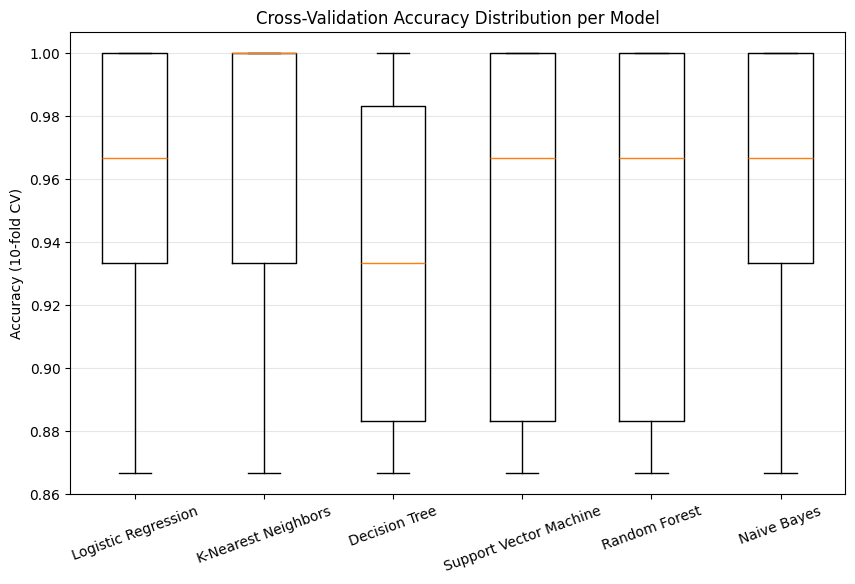


HOLD-OUT TEST SET RESULTS (single 80/20 split, for reference)


In [16]:
# Boxplot of CV scores
plt.figure(figsize=(10, 6))
plt.boxplot(cv_results.values(), labels=list(cv_results.keys()))
plt.xticks(rotation=20)
plt.ylabel("Accuracy (10-fold CV)")
plt.title("Cross-Validation Accuracy Distribution per Model")
plt.grid(axis='y', alpha=0.3)
plt.show()
print("\n" + "="*60)
print("HOLD-OUT TEST SET RESULTS (single 80/20 split, for reference)")
print("="*60)

In [17]:
holdout_results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    holdout_results[name] = acc
    print(f"\n{name} -> Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=list(species_map.values()), zero_division=0))


Logistic Regression -> Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


K-Nearest Neighbors -> Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


Decision Tree -> Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor

In [18]:
best_model_name = cv_summary.iloc[0]['Model']
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)

print("\n" + "="*60)
print("FINAL VERDICT")
print("="*60)
print(cv_summary.to_string(index=False))
print(f"\nBest model based on 10-fold cross-validation: {best_model_name}")
print(f"Mean CV Accuracy: {cv_summary.iloc[0]['Mean Accuracy']:.4f} "
      f"(+/- {cv_summary.iloc[0]['Std Dev']:.4f})")
print("\nWhy cross-validation and not the single train/test split:")
print("With only 150 samples, a single 80/20 split test set has just 30")
print("rows -- one or two misclassified flowers can swing accuracy by")
print("several percentage points. 10-fold CV trains/tests the model 10")
print("times on different slices of ALL the data, giving a far more")
print("reliable estimate of true performance and reducing the risk that")
print("a model 'looks best' purely due to a lucky train/test split.")
print("="*60)


FINAL VERDICT
                 Model  Mean Accuracy  Std Dev
   K-Nearest Neighbors       0.960000 0.053333
   Logistic Regression       0.953333 0.052068
           Naive Bayes       0.953333 0.052068
Support Vector Machine       0.946667 0.058119
         Random Forest       0.946667 0.058119
         Decision Tree       0.933333 0.051640

Best model based on 10-fold cross-validation: K-Nearest Neighbors
Mean CV Accuracy: 0.9600 (+/- 0.0533)

Why cross-validation and not the single train/test split:
With only 150 samples, a single 80/20 split test set has just 30
rows -- one or two misclassified flowers can swing accuracy by
several percentage points. 10-fold CV trains/tests the model 10
times on different slices of ALL the data, giving a far more
reliable estimate of true performance and reducing the risk that
a model 'looks best' purely due to a lucky train/test split.
